# Diagnostyka uszkodzeń łożysk na podstawie drgań
### CWRU Bearing Dataset – 48 kHz, obciążenie 1 HP

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import loadmat
from scipy.fft import fft, fftfreq
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 11


In [2]:
# Wczytanie surowych sygnałów z plików .mat
FS = 48_000

FILES = {
    "Normal":        "zbior/raw/Time_Normal_1_098.mat",
    "Ball 0.007":    "zbior/raw/B007_1_123.mat",
    "Ball 0.014":    "zbior/raw/B014_1_190.mat",
    "Ball 0.021":    "zbior/raw/B021_1_227.mat",
    "Inner 0.007":   "zbior/raw/IR007_1_110.mat",
    "Inner 0.014":   "zbior/raw/IR014_1_175.mat",
    "Inner 0.021":   "zbior/raw/IR021_1_214.mat",
    "Outer 0.007":   "zbior/raw/OR007_6_1_136.mat",
    "Outer 0.014":   "zbior/raw/OR014_6_1_202.mat",
    "Outer 0.021":   "zbior/raw/OR021_6_1_239.mat",
}

def load_signal(path):
    mat = loadmat(path)
    key = [k for k in mat.keys() if "time" in k.lower() and not k.startswith("_")][0]
    return mat[key].flatten()

signals = {}
for label, path in FILES.items():
    sig = load_signal(path)
    signals[label] = sig
    print(f"{label:15s}: {len(sig):>8,} próbek  ({len(sig)/FS:.2f} s)")


Normal         :  483,903 próbek  (10.08 s)
Ball 0.007     :  487,384 próbek  (10.15 s)
Ball 0.014     :  486,224 próbek  (10.13 s)
Ball 0.021     :  486,804 próbek  (10.14 s)
Inner 0.007    :  486,224 próbek  (10.13 s)
Inner 0.014    :  489,125 próbek  (10.19 s)
Inner 0.021    :  485,063 próbek  (10.11 s)
Outer 0.007    :  486,804 próbek  (10.14 s)
Outer 0.014    :  484,483 próbek  (10.09 s)
Outer 0.021    :  489,125 próbek  (10.19 s)


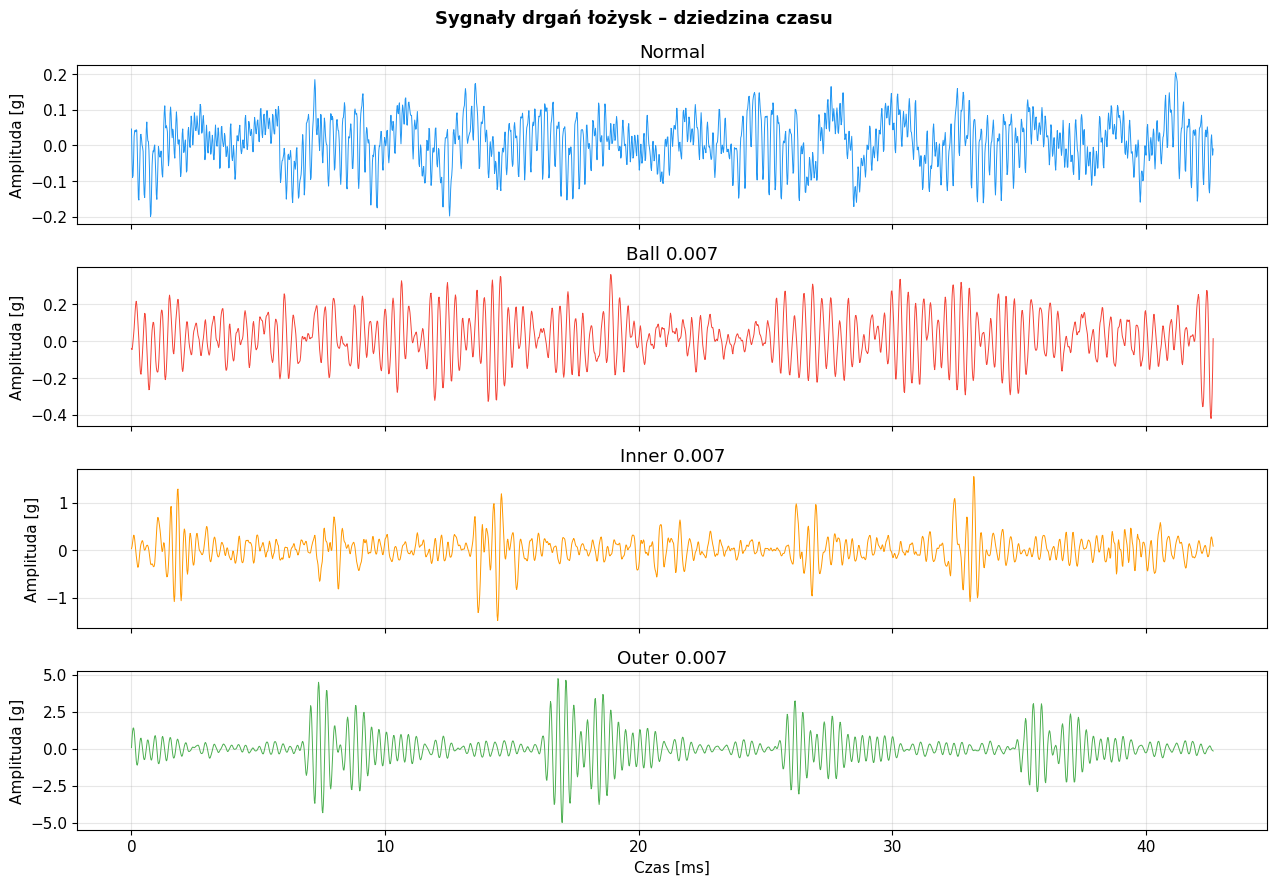

In [3]:
# Sygnały w dziedzinie czasu – po jednym przykładzie z każdej grupy
SHOW_LABELS = ["Normal", "Ball 0.007", "Inner 0.007", "Outer 0.007"]
COLORS = ["#2196F3", "#F44336", "#FF9800", "#4CAF50"]
N_SHOW = 2048
t_ms = np.arange(N_SHOW) / FS * 1000

fig, axes = plt.subplots(4, 1, figsize=(13, 9), sharex=True)
fig.suptitle("Sygnały drgań łożysk – dziedzina czasu", fontsize=13, fontweight="bold")

for ax, label, color in zip(axes, SHOW_LABELS, COLORS):
    ax.plot(t_ms, signals[label][:N_SHOW], color=color, linewidth=0.7)
    ax.set_ylabel("Amplituda [g]")
    ax.set_title(label)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Czas [ms]")
plt.tight_layout()
plt.show()


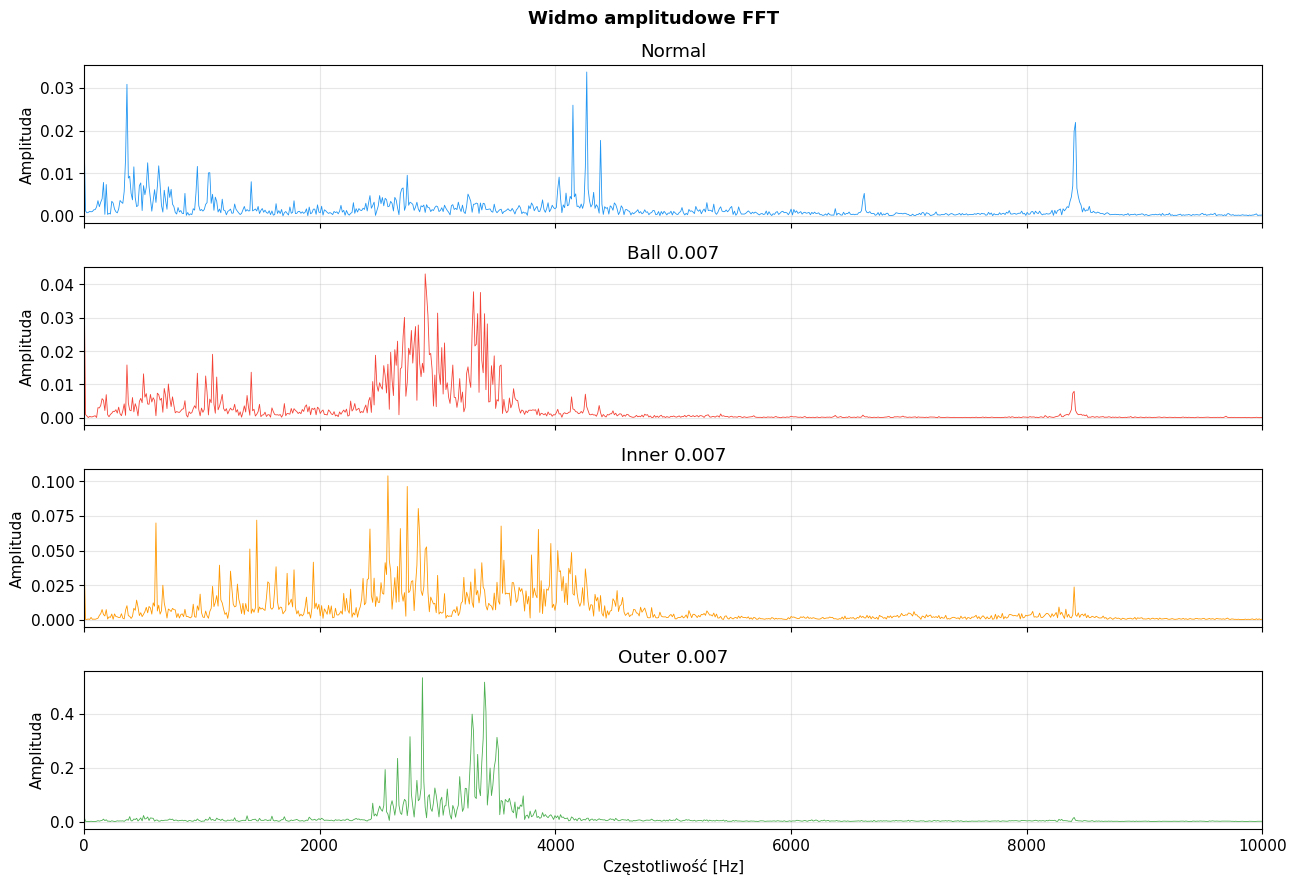

In [4]:
# Widma FFT – porównanie 4 stanów
N_FFT = 4096
freqs = fftfreq(N_FFT, d=1/FS)[:N_FFT//2]

fig, axes = plt.subplots(4, 1, figsize=(13, 9), sharex=True)
fig.suptitle("Widmo amplitudowe FFT", fontsize=13, fontweight="bold")

for ax, label, color in zip(axes, SHOW_LABELS, COLORS):
    spec = np.abs(fft(signals[label][:N_FFT]))[:N_FFT//2] * 2 / N_FFT
    ax.plot(freqs, spec, color=color, linewidth=0.6)
    ax.set_ylabel("Amplituda")
    ax.set_title(label)
    ax.set_xlim(0, 10000)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Częstotliwość [Hz]")
plt.tight_layout()
plt.show()


In [6]:
# Wczytanie gotowych cech z CSV
df = pd.read_csv("zbior/feature_time_48k_2048_load_1.csv")
print(df.shape)
print(df["fault"].value_counts())
df.head()


(2300, 10)
fault
Ball_007_1    230
Ball_014_1    230
Ball_021_1    230
IR_007_1      230
IR_014_1      230
IR_021_1      230
OR_007_6_1    230
OR_014_6_1    230
OR_021_6_1    230
Normal_1      230
Name: count, dtype: int64


,max,min,mean,sd,rms,skewness,kurtosis,crest,form,fault
0,0.35986,-0.41890,0.017840,0.122746,0.124006,-0.118571,-0.042219,2.901946,6.950855,Ball_007_1
1,0.46772,-0.36111,0.022255,0.132488,0.134312,0.174699,-0.081548,3.482334,6.035202,Ball_007_1
2,0.46855,-0.43809,0.020470,0.149651,0.151008,0.040339,-0.274069,3.102819,7.376926,Ball_007_1
3,0.58475,-0.54303,0.020960,0.157067,0.158422,-0.023266,0.134692,3.691097,7.558387,Ball_007_1
4,0.44685,-0.57891,0.022167,0.138189,0.139922,-0.081534,0.402783,3.193561,6.312085,Ball_007_1


In [7]:
# Uproszczenie etykiet do 4 grup: Normal / Ball / Inner Race / Outer Race
def simplify_label(fault):
    f = str(fault).lower()
    if "normal" in f: return "Normal"
    if "ball"   in f: return "Ball"
    if "ir"     in f: return "Inner Race"
    if "or"     in f: return "Outer Race"
    return fault

df["fault_group"] = df["fault"].apply(simplify_label)
df["fault_group"].value_counts()


fault_group
Ball          690
Inner Race    690
Outer Race    690
Normal        230
Name: count, dtype: int64

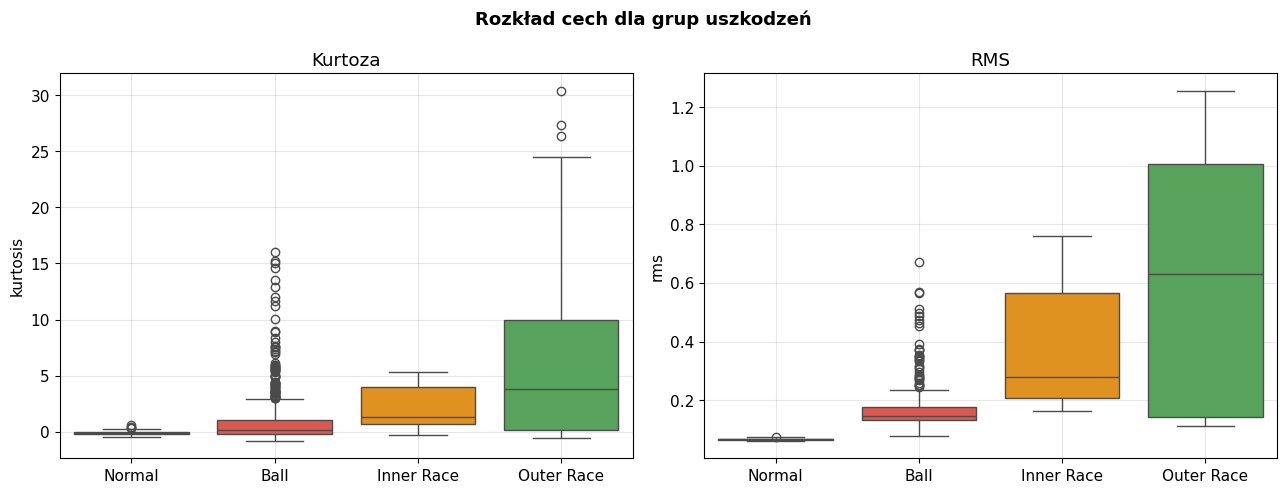

In [8]:
# Boxploty kurtoza i RMS
palette = {"Normal": "#2196F3", "Ball": "#F44336", "Inner Race": "#FF9800", "Outer Race": "#4CAF50"}
order   = ["Normal", "Ball", "Inner Race", "Outer Race"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Rozkład cech dla grup uszkodzeń", fontsize=13, fontweight="bold")

sns.boxplot(data=df, x="fault_group", y="kurtosis", order=order, palette=palette, ax=axes[0])
axes[0].set_title("Kurtoza")
axes[0].set_xlabel("")
axes[0].grid(True, alpha=0.3)

sns.boxplot(data=df, x="fault_group", y="rms", order=order, palette=palette, ax=axes[1])
axes[1].set_title("RMS")
axes[1].set_xlabel("")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


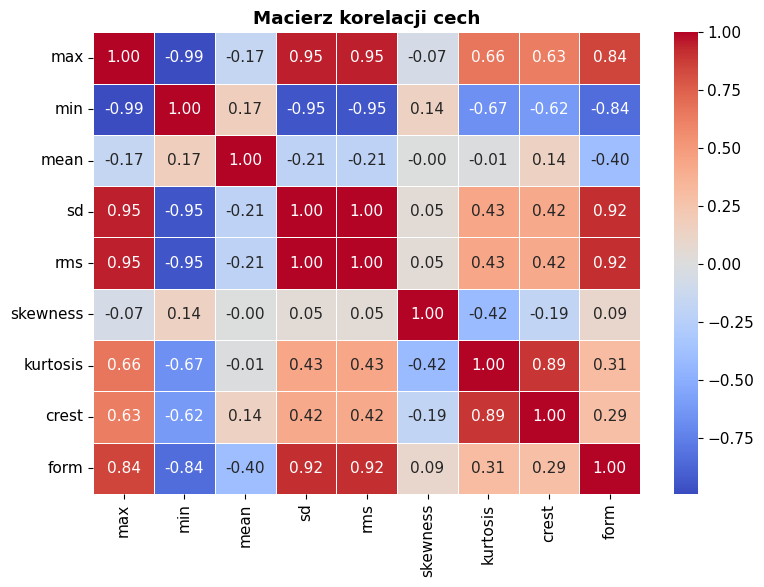

In [9]:
# Macierz korelacji cech
feature_cols = ["max", "min", "mean", "sd", "rms", "skewness", "kurtosis", "crest", "form"]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df[feature_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax)
ax.set_title("Macierz korelacji cech", fontweight="bold")
plt.tight_layout()
plt.show()


In [12]:
# Klasyfikacja Random Forest – 10 klas szczegółowych
X = df[feature_cols].values
le = LabelEncoder()
y = le.fit_transform(df["fault"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

clf = RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Dokładność: {acc*100:.1f}%")
print(classification_report(y_test, y_pred, target_names=le.classes_))


Dokładność: 94.8%
              precision    recall  f1-score   support

  Ball_007_1       0.95      0.91      0.93        57
  Ball_014_1       0.96      0.91      0.94        57
  Ball_021_1       0.90      0.79      0.84        58
    IR_007_1       1.00      1.00      1.00        58
    IR_014_1       1.00      1.00      1.00        58
    IR_021_1       0.92      1.00      0.96        57
    Normal_1       1.00      1.00      1.00        58
  OR_007_6_1       0.98      1.00      0.99        57
  OR_014_6_1       0.79      0.88      0.83        57
  OR_021_6_1       0.98      0.98      0.98        58

    accuracy                           0.95       575
   macro avg       0.95      0.95      0.95       575
weighted avg       0.95      0.95      0.95       575



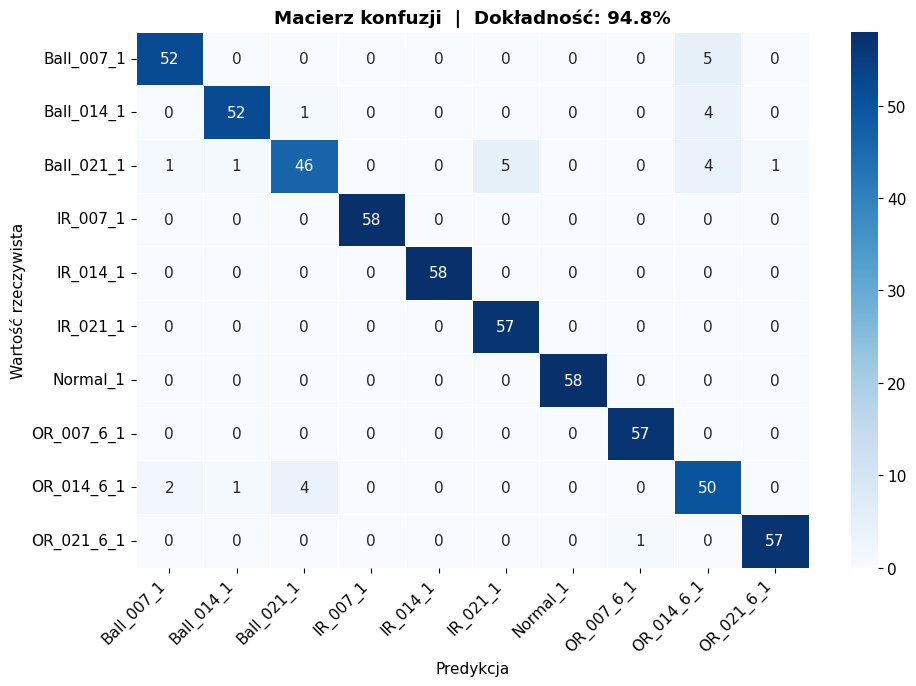

In [13]:
# Macierz konfuzji
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.5, ax=ax)
ax.set_xlabel("Predykcja")
ax.set_ylabel("Wartość rzeczywista")
ax.set_title(f"Macierz konfuzji  |  Dokładność: {acc*100:.1f}%", fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


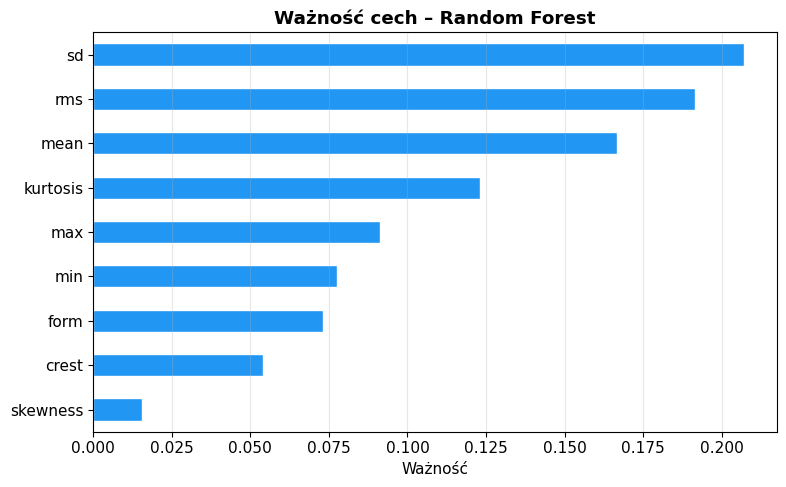

In [14]:
# Ważność cech
importances = pd.Series(clf.feature_importances_, index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot.barh(ax=ax, color="#2196F3", edgecolor="white")
ax.set_title("Ważność cech – Random Forest", fontweight="bold")
ax.set_xlabel("Ważność")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()
